# Quesetion 10: 10. Is there a correlation between a player's height and their ranking?

Using `home_team` and `away_team`

In [21]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

In [22]:
MINI_PROJECT_ROOT = Path.cwd().parents[2]

DATA_ROOT = (
    MINI_PROJECT_ROOT
    / "Tennis Schema"
    / "tennis_data"
)

PROCESSED_ROOT = DATA_ROOT / "processed"

TEAM_DATA_ROOT = DATA_ROOT / "Data"

In [23]:
# Load Player Height and Ranking Data

home_team = pd.read_parquet(TEAM_DATA_ROOT / "home_team.parquet")
away_team = pd.read_parquet(TEAM_DATA_ROOT / "away_team.parquet")
players = pd.concat([home_team[["player_id", "height", "current_rank"]], away_team[["player_id", "height", "current_rank"]]])

players.head()

,player_id,height,current_rank
0,287803,1.83,86.0
1,287803,1.83,86.0
2,62790,1.80,99.0
3,62790,1.80,99.0
4,64580,1.88,31.0


In [24]:
# Keep One Latest Record per Player
players = pd.concat([
    home_team[["player_id", "height", "current_rank", "snapshot_date"]],
    away_team[["player_id", "height", "current_rank", "snapshot_date"]]])

# Remove NaNs
players_clean = (players.dropna(subset=["height", "current_rank"]).sort_values("snapshot_date").drop_duplicates("player_id", keep="last"))

players_clean[["player_id", "height", "current_rank"]].head()

,player_id,height,current_rank
132,48455,1.69,71.0
70,386194,1.85,730.0
116,377489,1.91,409.0
665,384145,2.03,1107.0
1116,46661,1.62,736.0


In [25]:
# Calculate the Correlation Between Height and Ranking
height_rank_corr = players_clean["height"].corr(players_clean["current_rank"])

round(height_rank_corr, 3)

np.float64(0.103)

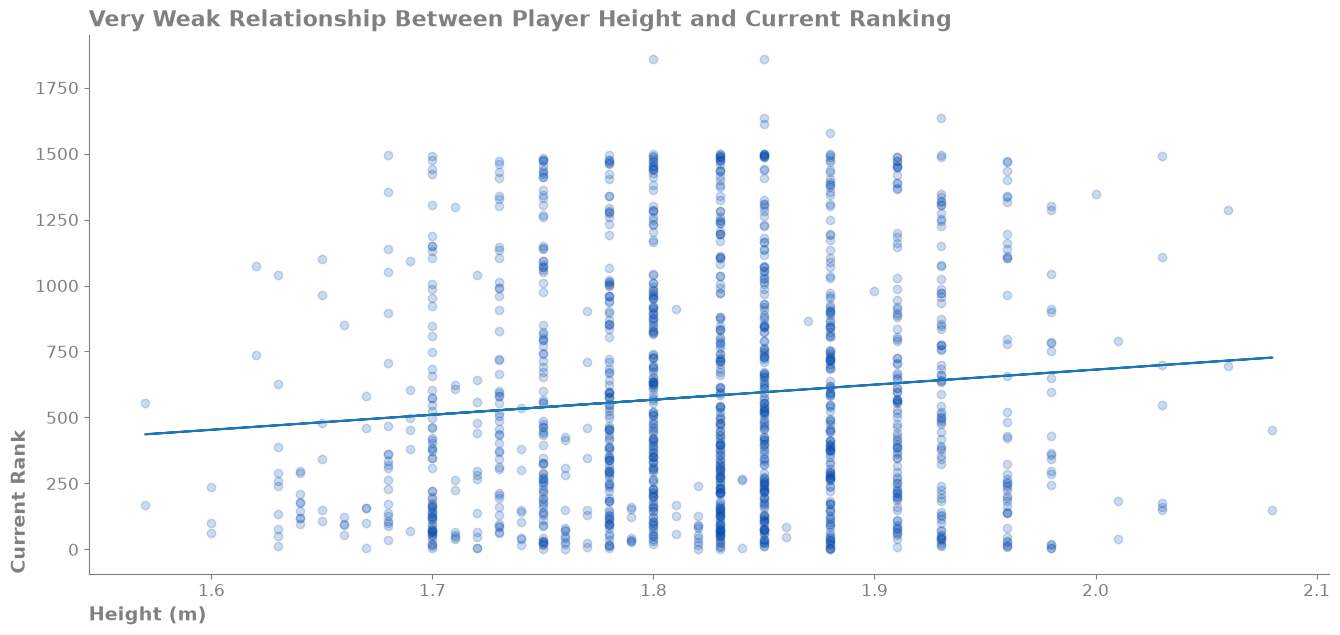

In [26]:
fig, ax = plt.subplots(figsize=(16, 7))

ax.scatter(
    x=players_clean["height"],
    y=players_clean["current_rank"],
    alpha=.2,
    color='#0047AB')

ax.spines[["right", "top"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("gray")

ax.set_title(
    "Very Weak Relationship Between Player Height and Current Ranking",
    loc="left",
    weight="bold",
    color="gray",
    fontsize=16,)

ax.set_xlabel(
    "Height (m)",
    loc="left",
    weight="bold",
    color="gray",
    fontsize=14)

ax.set_ylabel(
    "Current Rank",
    loc="bottom",
    weight="bold",
    color="gray",
    fontsize=14)

ax.tick_params(axis="x", colors="gray", labelsize="large")
ax.tick_params(axis="y", colors="gray", labelsize="large")

m, b = np.polyfit(players_clean["height"], players_clean["current_rank"], 1)

ax.plot(players_clean["height"], m * players_clean["height"] + b)

plt.show()

The Correlation between player's height and their rank is only 0.103 and therefore there is a weak positive relationship. 